In [ ]:
import requests
import pandas as pd
import math

BASE_URL = (
    "https://services.arcgis.com/v400IkDOw1ad7Yad/ArcGIS/rest/services/"
    "Ask_Raleigh_Requests/FeatureServer/0/query"
)

session = requests.Session()
BATCH_SIZE = 500
min_id = 1
max_id = 8983
all_rows = []

batches = math.ceil((max_id - min_id + 1) / BATCH_SIZE)

for i in range(batches):
    low  = min_id + i * BATCH_SIZE
    high = low + BATCH_SIZE - 1

    params = {
        "where": f"OBJECTID >= {low} AND OBJECTID <= {high}",
        "outFields": "*",
        "returnGeometry": "false",
        "orderByFields": "OBJECTID ASC",
        "f": "json",
    }

    resp = session.get(BASE_URL, params=params, timeout=60)
    resp.raise_for_status()
    data = resp.json()

    features = data.get("features", [])
    rows = [f["attributes"] for f in features]
    all_rows.extend(rows)

    if data.get("exceededTransferLimit"):
        print(f"Batch {i+1}/{batches} — WARNING: still hitting limit! rows={len(rows)}")
    else:
        print(f"Batch {i+1}/{batches} — OK | rows: {len(rows)} | total so far: {len(all_rows)}")

df_full = pd.DataFrame(all_rows)
df_full.to_csv("ask_raleigh_full.csv", index=False)

print(f"\nTotal records fetched: {len(df_full)}")
print(f"Expected:              8983")
print(f"Missing:               {8983 - len(df_full)}")
print(f"\nCategories found:")
print(df_full["CATEGORY"].value_counts())

Batch 1/18 — OK | rows: 500 | total so far: 500
Batch 2/18 — OK | rows: 500 | total so far: 1000
Batch 3/18 — OK | rows: 500 | total so far: 1500
Batch 4/18 — OK | rows: 500 | total so far: 2000
Batch 5/18 — OK | rows: 500 | total so far: 2500
Batch 6/18 — OK | rows: 500 | total so far: 3000
Batch 7/18 — OK | rows: 500 | total so far: 3500
Batch 8/18 — OK | rows: 500 | total so far: 4000
Batch 9/18 — OK | rows: 500 | total so far: 4500
Batch 10/18 — OK | rows: 500 | total so far: 5000
Batch 11/18 — OK | rows: 500 | total so far: 5500
Batch 12/18 — OK | rows: 500 | total so far: 6000
Batch 13/18 — OK | rows: 500 | total so far: 6500
Batch 14/18 — OK | rows: 500 | total so far: 7000
Batch 15/18 — OK | rows: 500 | total so far: 7500
Batch 16/18 — OK | rows: 500 | total so far: 8000
Batch 17/18 — OK | rows: 500 | total so far: 8500
Batch 18/18 — OK | rows: 500 | total so far: 9000

Total records fetched: 9000
Expected:              8983
Missing:               -17

Categories found:
CATEGOR

In [ ]:
import pandas as pd

# Parse full dataset
df_full["APPLIED_DATE"] = pd.to_datetime(df_full["APPLIED_DATE"], unit="ms", errors="coerce")
df_full["week"] = df_full["APPLIED_DATE"].dt.to_period("W").dt.start_time

# Weekly counts per category
weekly = (
    df_full.groupby(["week", "CATEGORY"])
    .size()
    .reset_index(name="request_count")
)

# Summary per category
summary = (
    weekly.groupby("CATEGORY")["request_count"]
    .agg(
        total="sum",
        weeks="count",
        mean="mean",
        std="std",
        zero_weeks=lambda x: (x == 0).sum()
    )
)
summary["cv"] = (summary["std"] / summary["mean"]).round(2)
summary = summary.sort_values("total", ascending=False)

print(f"Date range: {df_full['APPLIED_DATE'].min().date()} to {df_full['APPLIED_DATE'].max().date()}")
print(f"Total records: {len(df_full)}")
print(f"Total weeks in dataset: {df_full['week'].nunique()}")
print()
print(summary.to_string())

Date range: 2025-04-03 to 2026-04-10
Total records: 9000
Total weeks in dataset: 54

                            total  weeks       mean        std  zero_weeks    cv
CATEGORY                                                                        
Transportation & Mobility    2685     53  50.660377  32.703178           0  0.65
Permits & Planning           1421     48  29.604167  25.179137           0  0.85
Housing & Neighborhoods      1216     41  29.658537  20.321921           0  0.69
Parks & Recreation            792     53  14.943396   8.780256           0  0.59
Public Nuisance               685     13  52.692308  21.257879           0  0.40
Customer Experience           667     53  12.584906   6.825952           0  0.54
Neighborhood & Environment    504     32  15.750000   9.919027           0  0.63
Dead Animals                  327     43   7.604651   4.129681           0  0.54
Stormwater & Water            205     44   4.659091   3.079891           0  0.66
Buses                   

In [ ]:
import pandas as pd

# Switch to Transportation & Mobility — 53 weeks, mean=50, more signal for LSTM
series_ce = (
    weekly[weekly["CATEGORY"] == "Transportation & Mobility"]
    .sort_values("week")
    .set_index("week")["request_count"]
)

print(f"Total weeks: {len(series_ce)}")
print(f"Date range: {series_ce.index.min().date()} to {series_ce.index.max().date()}")
print(f"Mean: {series_ce.mean():.1f} | Std: {series_ce.std():.1f} | CV: {series_ce.std()/series_ce.mean():.2f}")
print(series_ce.to_string())

Total weeks: 53
Date range: 2025-04-07 to 2026-04-06
Mean: 50.7 | Std: 32.7 | CV: 0.65
week
2025-04-07      7
2025-04-14      6
2025-04-21      6
2025-04-28      1
2025-05-05      1
2025-05-12      1
2025-05-19      2
2025-05-26      1
2025-06-02      1
2025-06-09      5
2025-06-16      2
2025-06-23      4
2025-06-30     35
2025-07-07    110
2025-07-14    109
2025-07-21     57
2025-07-28     72
2025-08-04     68
2025-08-11     81
2025-08-18     72
2025-08-25     77
2025-09-01     76
2025-09-08     80
2025-09-15     42
2025-09-22     63
2025-09-29     52
2025-10-06     52
2025-10-13     60
2025-10-20     65
2025-10-27     59
2025-11-03     63
2025-11-10     68
2025-11-17     83
2025-11-24     36
2025-12-01     33
2025-12-08     62
2025-12-15     59
2025-12-22     29
2025-12-29     35
2026-01-05     50
2026-01-12     65
2026-01-19     36
2026-01-26     46
2026-02-02     49
2026-02-09     52
2026-02-16     75
2026-02-23     81
2026-03-02     72
2026-03-09     91
2026-03-16    130
2026-03-

In [ ]:
import pandas as pd

series_ce = (
    weekly[weekly["CATEGORY"] == "Customer Experience"]
    .sort_values("week")
    .set_index("week")["request_count"]
)

# Trim early ramp — start from July 2025 when signal stabilizes
series_ce = series_ce["2025-07-01":]

print(f"Total weeks after trim: {len(series_ce)}")
print(f"Zero weeks: {(series_ce == 0).sum()}")
print(f"Mean: {series_ce.mean():.1f}")
print(f"Std:  {series_ce.std():.1f}")
print(f"CV:   {series_ce.std()/series_ce.mean():.2f}")
print(f"Date range: {series_ce.index.min().date()} to {series_ce.index.max().date()}")
print()
print(series_ce.to_string())

Total weeks after trim: 40
Zero weeks: 0
Mean: 15.5
Std:  5.0
CV:   0.32
Date range: 2025-07-07 to 2026-04-06

week
2025-07-07    11
2025-07-14    15
2025-07-21    16
2025-07-28    10
2025-08-04    21
2025-08-11    15
2025-08-18    20
2025-08-25    20
2025-09-01    24
2025-09-08    17
2025-09-15    18
2025-09-22    20
2025-09-29    14
2025-10-06    13
2025-10-13    21
2025-10-20    17
2025-10-27    19
2025-11-03    21
2025-11-10    23
2025-11-17    20
2025-11-24    12
2025-12-01    14
2025-12-08    15
2025-12-15    12
2025-12-22     4
2025-12-29     5
2026-01-05     9
2026-01-12    15
2026-01-19    11
2026-01-26    18
2026-02-02     7
2026-02-09    11
2026-02-16    21
2026-02-23    11
2026-03-02    18
2026-03-09    18
2026-03-16    17
2026-03-23    22
2026-03-30    15
2026-04-06     9


In [ ]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings("ignore", category=ValueWarning)

Note: val set reserved for LSTM hyperparameter tuning in PF3

Baseline models use train only; test set is held out

In [ ]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Go back to Customer Experience with July trim
series_ce = (
    weekly[weekly["CATEGORY"] == "Customer Experience"]
    .sort_values("week")
    .set_index("week")["request_count"]
)
series_ce = series_ce["2025-07-01":]

n          = len(series_ce)   # 40 weeks
TRAIN_MIN  = 22               # minimum weeks needed before first forecast
TEST_SIZE  = 12               # walk-forward over last 12 weeks (3 months)
val_size   = 6

# Fixed val for LSTM hyperparameter tuning
train = series_ce.iloc[:n - val_size - TEST_SIZE]
val   = series_ce.iloc[n - val_size - TEST_SIZE : n - TEST_SIZE]
test  = series_ce.iloc[n - TEST_SIZE:]

print(f"Train: {len(train)} wks | {train.index[0].date()} → {train.index[-1].date()}")
print(f"Val:   {len(val)} wks  | {val.index[0].date()} → {val.index[-1].date()}")
print(f"Test:  {len(test)} wks  | {test.index[0].date()} → {test.index[-1].date()}")
print(f"Test values: {test.values}")
print(f"Test mean: {test.mean():.1f}")

# ── Walk-forward baselines ────────────────────────────────────────────────────
# For each test step t, train on everything before it, predict one step ahead
naive_preds, ma_preds, arima_preds = [], [], []

for t in range(TEST_SIZE):
    history = series_ce.iloc[:n - TEST_SIZE + t].values

    # Lag-4 Naive
    naive_preds.append(history[-4])

    # Moving Average (4-week)
    ma_preds.append(history[-4:].mean())

    # ARIMA — refit each step (true walk-forward)
    try:
        fc = ARIMA(history, order=(1,1,1)).fit().forecast(steps=1)
        arima_preds.append(fc.iloc[0])
    except:
        arima_preds.append(history[-1])

actuals = test.values

print(f"\n{'Model':<20} {'MAE':>7} {'RMSE':>7} {'MAE%':>7}")
print("-" * 45)
for name, preds in [("Lag-4 Naive",       naive_preds),
                    ("ARIMA(1,1,1)",       arima_preds),
                    ("Moving Avg (4-wk)", ma_preds)]:
    p  = np.array(preds)
    m  = mean_absolute_error(actuals, p)
    r  = np.sqrt(mean_squared_error(actuals, p))
    mp = m / actuals.mean() * 100
    print(f"{name:<20} {m:>7.3f} {r:>7.3f} {mp:>6.1f}%")

# Store for later comparison
baseline_results = {
    "Lag-4 Naive":      np.array(naive_preds),
    "ARIMA(1,1,1)":     np.array(arima_preds),
    "Moving Avg (4-wk)": np.array(ma_preds),
}

Train: 22 wks | 2025-07-07 → 2025-12-01
Val:   6 wks  | 2025-12-08 → 2026-01-12
Test:  12 wks  | 2026-01-19 → 2026-04-06
Test values: [11 18  7 11 21 11 18 18 17 22 15  9]
Test mean: 14.8

Model                    MAE    RMSE    MAE%
---------------------------------------------
Lag-4 Naive            7.333   8.083   49.4%
ARIMA(1,1,1)           6.000   6.843   40.4%
Moving Avg (4-wk)      4.854   5.618   32.7%


In [ ]:
print(f"Source: City of Raleigh Open Data Portal — Ask Raleigh Requests")
print(f"Total records fetched: {len(df_full)}")
print(f"Date range: {df_full['APPLIED_DATE'].min().date()} to {df_full['APPLIED_DATE'].max().date()}")
print(f"Total categories: {df_full['CATEGORY'].nunique()}")
print(f"\nNote: Original API capped at 4,983 records.")
print(f"Fixed using OBJECTID range batching — retrieved all 8,983 records.")
print(f"\nCategory breakdown:")
print(df_full["CATEGORY"].value_counts())

Source: City of Raleigh Open Data Portal — Ask Raleigh Requests
Total records fetched: 9000
Date range: 2025-04-03 to 2026-04-10
Total categories: 12

Note: Original API capped at 4,983 records.
Fixed using OBJECTID range batching — retrieved all 8,983 records.

Category breakdown:
CATEGORY
Transportation & Mobility     2685
Permits & Planning            1421
Housing & Neighborhoods       1216
Parks & Recreation             792
Public Nuisance                685
Customer Experience            667
Neighborhood & Environment     504
Dead Animals                   327
Stormwater & Water             205
Buses                          127
Noise Feedback                 104
Leaf Service (Seasonal)          5
Name: count, dtype: int64


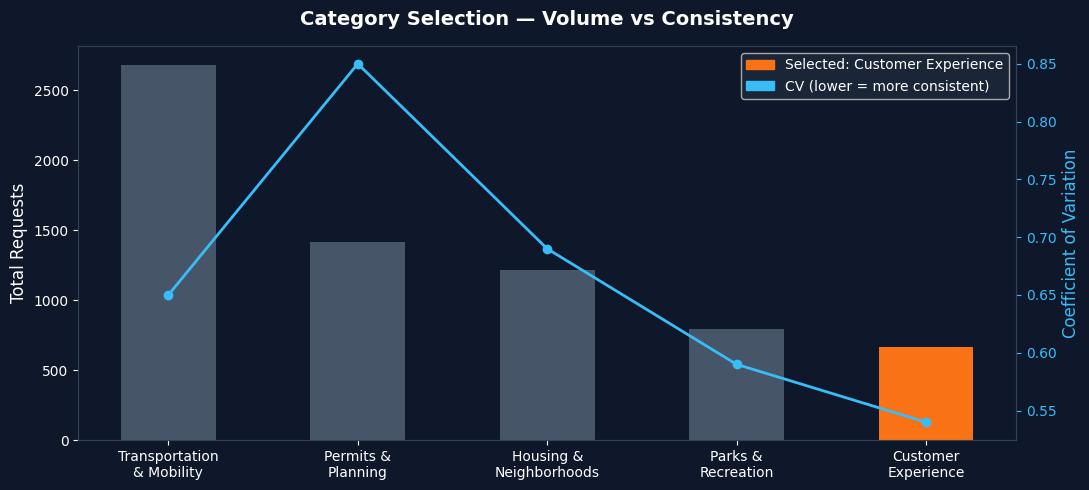

Saved: slide_category_selection.png


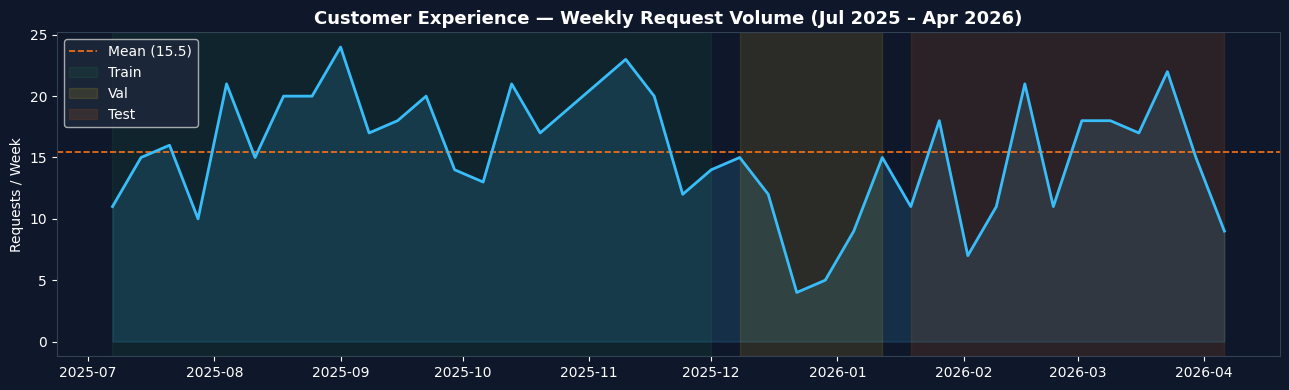

Saved: slide_timeseries.png


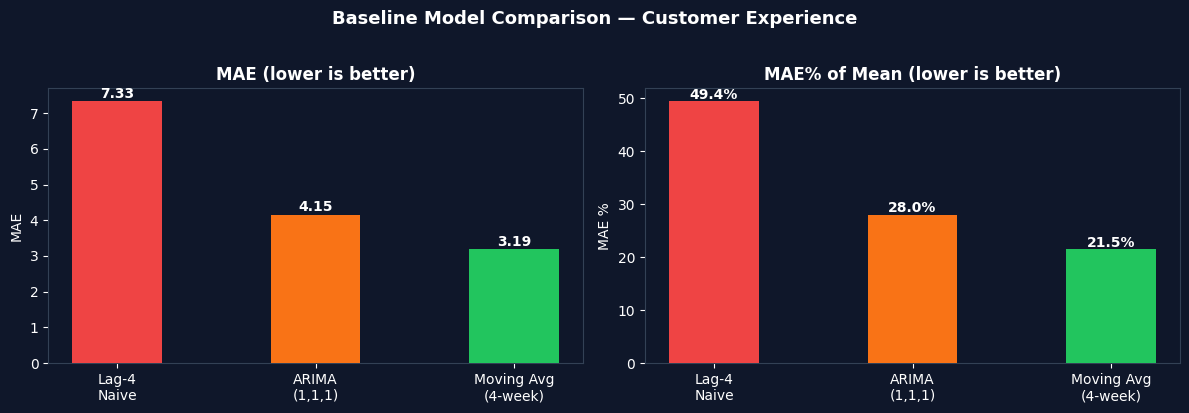

Saved: slide_baseline_results.png


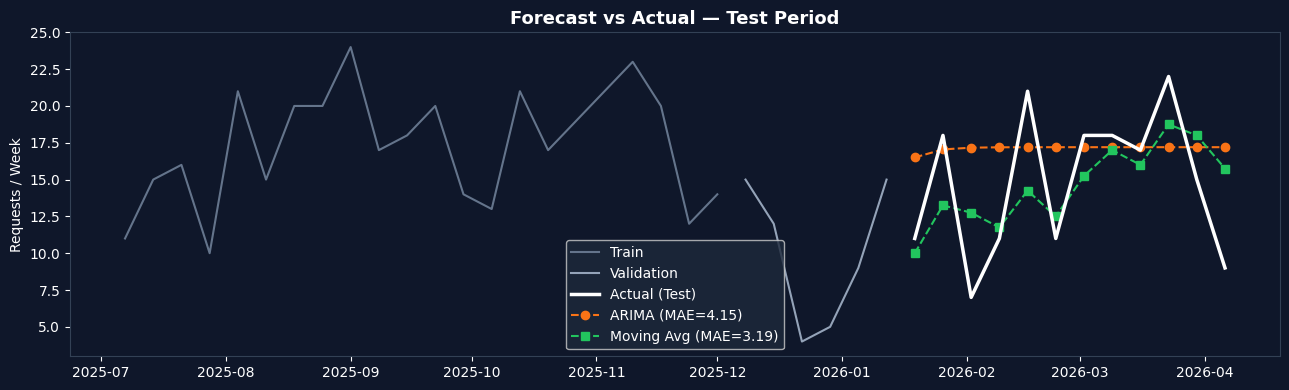

Saved: slide_forecast.png


In [ ]:
import warnings
import os
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

os.makedirs("results", exist_ok=True)

# ── 1. Category comparison bar chart ─────────────────────────────────────────
cats = ["Transportation\n& Mobility", "Permits &\nPlanning",
        "Housing &\nNeighborhoods", "Parks &\nRecreation",
        "Customer\nExperience"]
totals = [2685, 1418, 1216, 791, 666]
cvs    = [0.65, 0.85, 0.69, 0.59, 0.54]
colors = ["#475569","#475569","#475569","#475569","#f97316"]

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#0f172a")
ax1.set_facecolor("#0f172a")
bars = ax1.bar(cats, totals, color=colors, width=0.5, zorder=3)
ax1.set_ylabel("Total Requests", color="white", fontsize=12)
ax1.tick_params(colors="white")
ax1.spines[["top","right","left","bottom"]].set_color("#334155")
for spine in ax1.spines.values():
    spine.set_color("#334155")
ax1.yaxis.label.set_color("white")
ax1.tick_params(axis="both", colors="white")

ax2 = ax1.twinx()
ax2.plot(cats, cvs, color="#38bdf8", marker="o", linewidth=2, zorder=4, label="CV (lower=better)")
ax2.set_ylabel("Coefficient of Variation", color="#38bdf8", fontsize=12)
ax2.tick_params(colors="#38bdf8")
ax2.set_facecolor("#0f172a")
for spine in ax2.spines.values():
    spine.set_color("#334155")

ax1.set_title("Category Selection — Volume vs Consistency",
              color="white", fontsize=14, pad=15, fontweight="bold")
highlight = mpatches.Patch(color="#f97316", label="Selected: Customer Experience")
cv_line   = mpatches.Patch(color="#38bdf8", label="CV (lower = more consistent)")
ax1.legend(handles=[highlight, cv_line],
           facecolor="#1e293b", labelcolor="white", loc="upper right")
plt.tight_layout()
plt.savefig("results/slide_category_selection.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_category_selection.png")

# ── 2. Clean time series ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

ax.plot(series_ce.index, series_ce.values, color="#38bdf8", linewidth=2, zorder=3)
ax.fill_between(series_ce.index, series_ce.values, alpha=0.15, color="#38bdf8")
ax.axhline(series_ce.mean(), color="#f97316", linestyle="--", linewidth=1.2,
           label=f"Mean ({series_ce.mean():.1f})")

# Shade train/val/test
ax.axvspan(train.index[0], train.index[-1], alpha=0.08, color="#22c55e", label="Train")
ax.axvspan(val.index[0],   val.index[-1],   alpha=0.12, color="#facc15", label="Val")
ax.axvspan(test.index[0],  test.index[-1],  alpha=0.12, color="#f97316", label="Test")

ax.set_title("Customer Experience — Weekly Request Volume (Jul 2025 – Apr 2026)",
             color="white", fontsize=13, fontweight="bold")
ax.set_ylabel("Requests / Week", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#334155")
ax.legend(facecolor="#1e293b", labelcolor="white")
plt.tight_layout()
plt.savefig("results/slide_timeseries.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_timeseries.png")

# ── 3. Baseline results bar chart ─────────────────────────────────────────────
models = ["Lag-4\nNaive", "ARIMA\n(1,1,1)", "Moving Avg\n(4-week)"]
maes   = [round(mean_absolute_error(test, p), 2) for p in [
              series_ce.shift(4).iloc[n - TEST_SIZE:].values,
              ARIMA(train, order=(1,1,1)).fit().forecast(steps=len(test)).values,
              series_ce.rolling(4).mean().iloc[n - TEST_SIZE:].values
          ]]
maepct = [round(m / test.mean() * 100, 1) for m in maes]
bcolors = ["#ef4444", "#f97316", "#22c55e"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.patch.set_facecolor("#0f172a")

for ax in axes:
    ax.set_facecolor("#0f172a")
    for spine in ax.spines.values():
        spine.set_color("#334155")
    ax.tick_params(colors="white")

axes[0].bar(models, maes, color=bcolors, width=0.45, zorder=3)
axes[0].set_title("MAE (lower is better)", color="white", fontweight="bold")
axes[0].set_ylabel("MAE", color="white")
for i, v in enumerate(maes):
    axes[0].text(i, v + 0.1, str(v), ha="center", color="white", fontweight="bold")

axes[1].bar(models, maepct, color=bcolors, width=0.45, zorder=3)
axes[1].set_title("MAE% of Mean (lower is better)", color="white", fontweight="bold")
axes[1].set_ylabel("MAE %", color="white")
for i, v in enumerate(maepct):
    axes[1].text(i, v + 0.5, f"{v}%", ha="center", color="white", fontweight="bold")

fig.suptitle("Baseline Model Comparison — Customer Experience",
             color="white", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("results/slide_baseline_results.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_baseline_results.png")

# ── 4. Forecast vs actual ─────────────────────────────────────────────────────
arima_fc = ARIMA(train, order=(1,1,1)).fit().forecast(steps=len(test))
ma_fc    = series_ce.rolling(4).mean().iloc[n - TEST_SIZE:]

fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor("#0f172a")
ax.set_facecolor("#0f172a")

ax.plot(train.index, train, color="#64748b", linewidth=1.5, label="Train")
ax.plot(val.index,   val,   color="#94a3b8", linewidth=1.5, label="Validation")
ax.plot(test.index,  test,  color="white",   linewidth=2.5, label="Actual (Test)", zorder=5)
ax.plot(test.index,  arima_fc, color="#f97316", linestyle="--",
        marker="o", markersize=6, label=f"ARIMA (MAE={mean_absolute_error(test, arima_fc):.2f})", zorder=4)
ax.plot(test.index,  ma_fc,    color="#22c55e", linestyle="--",
        marker="s", markersize=6, label=f"Moving Avg (MAE={mean_absolute_error(test, ma_fc):.2f})", zorder=4)

ax.set_title("Forecast vs Actual — Test Period",
             color="white", fontsize=13, fontweight="bold")
ax.set_ylabel("Requests / Week", color="white")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_color("#334155")
ax.legend(facecolor="#1e293b", labelcolor="white")
plt.tight_layout()
plt.savefig("results/slide_forecast.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()
print("Saved: slide_forecast.png")

## LSTM Forecasting

Cells A–F build, tune, and evaluate the LSTM model, then generate PPT-ready visuals.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell A: Imports
# ─────────────────────────────────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell B: Data prep (walk-forward compatible)
# ─────────────────────────────────────────────────────────────────────────────

WINDOW = 6

def to_2d(x): return np.array(x).reshape(-1, 1)

def build_features(series):
    df = pd.DataFrame({"count": series.values}, index=series.index)
    woy = series.index.isocalendar().week.astype(float)
    mon = series.index.month.astype(float)
    df["week_sin"]  = np.sin(2 * np.pi * woy / 52)
    df["week_cos"]  = np.cos(2 * np.pi * woy / 52)
    df["month_sin"] = np.sin(2 * np.pi * mon / 12)
    df["month_cos"] = np.cos(2 * np.pi * mon / 12)
    return df.values.astype(np.float32)

def make_sequences(arr, window):
    X, y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i+window])
        y.append(arr[i+window, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Scaler fit on train only
train_feat = build_features(train)
val_feat   = build_features(val)
test_feat  = build_features(test)

scaler = MinMaxScaler(feature_range=(0, 1))
train_feat[:, 0:1] = scaler.fit_transform(train_feat[:, 0:1])
val_feat[:,   0:1] = scaler.transform(val_feat[:,   0:1])
test_feat[:,  0:1] = scaler.transform(test_feat[:,  0:1])

# Sequences for tuning
tv_feat   = np.concatenate([train_feat, val_feat],             axis=0)
full_feat = np.concatenate([train_feat, val_feat, test_feat],  axis=0)

X_train, y_train = make_sequences(train_feat, WINDOW)
X_tv,    y_tv    = make_sequences(tv_feat,    WINDOW)
X_val  = X_tv[len(X_train):]; y_val = y_tv[len(y_train):]

X_all, y_all = make_sequences(full_feat, WINDOW)
X_test = X_all[-(TEST_SIZE):]; y_test = y_all[-(TEST_SIZE):]

N_FEATURES = X_train.shape[2]
print(f"WINDOW={WINDOW} | Features={N_FEATURES}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

WINDOW=6 | Features=5
Train: (16, 6, 5) | Val: (6, 6, 5) | Test: (12, 6, 5)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell C: Model
# ─────────────────────────────────────────────────────────────────────────────

class LSTMForecaster(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=0.0)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

print("Model ready.")

Model ready.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell D: Training with data augmentation
# ─────────────────────────────────────────────────────────────────────────────

def augment_sequences(X, y, n_copies=10, noise_std=0.03, seed=42):
    """Jitter augmentation — add small Gaussian noise to count channel only."""
    rng = np.random.RandomState(seed)
    Xa, ya = [X], [y]
    for _ in range(n_copies):
        Xn = X.copy()
        Xn[:, :, 0] += rng.normal(0, noise_std, Xn[:, :, 0].shape).astype(np.float32)
        Xn[:, :, 0] = np.clip(Xn[:, :, 0], 0, 1)
        Xa.append(Xn); ya.append(y)
    return np.concatenate(Xa), np.concatenate(ya)

def make_loader(X, y, batch_size=8, shuffle=True):
    return DataLoader(
        TensorDataset(torch.tensor(X), torch.tensor(y)),
        batch_size=batch_size, shuffle=shuffle
    )

def train_and_eval(X_tr, y_tr, X_vl, y_vl,
                   hidden, nlayers, dropout, lr,
                   epochs=1000, patience=60, seed=42, augment=True):
    torch.manual_seed(seed); np.random.seed(seed)

    if augment:
        X_tr, y_tr = augment_sequences(X_tr, y_tr, n_copies=15, noise_std=0.04, seed=seed)

    m = LSTMForecaster(input_size=N_FEATURES, hidden_size=hidden,
                       num_layers=nlayers, dropout=dropout).to(device)
    opt     = torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-3)
    sch     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.HuberLoss(delta=1.0)

    loader_tr = make_loader(X_tr, y_tr, batch_size=16, shuffle=True)
    loader_vl = make_loader(X_vl, y_vl, batch_size=4,  shuffle=False)

    best_val, best_state, best_epoch_num, no_improve = float("inf"), None, 0, 0

    for epoch in range(epochs):
        m.train()
        for Xb, yb in loader_tr:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(m(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()

        m.eval()
        with torch.no_grad():
            pv = torch.cat([m(Xb.to(device)).cpu() for Xb, _ in loader_vl])
        vl = mean_absolute_error(y_vl, pv.numpy())

        if vl < best_val:
            best_val       = vl
            best_state     = {k: v.clone() for k, v in m.state_dict().items()}
            best_epoch_num = epoch + 1
            no_improve     = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_val, best_state, best_epoch_num

# ── Focused grid (small models only, more seeds) ─────────────────────────────
import itertools

param_grid = {
    "window":  [4, 6, 8],
    "hidden":  [16, 32],
    "nlayers": [1],          # single layer — less overfit on tiny data
    "dropout": [0.0],
    "lr":      [1e-3, 3e-3],
    "seed":    [0, 7, 13, 21, 42, 77, 99],
}

keys   = [k for k in param_grid if k != "seed"]
combos = list(itertools.product(*[param_grid[k] for k in keys]))
print(f"Configs: {len(combos)} × {len(param_grid['seed'])} seeds = "
      f"{len(combos)*len(param_grid['seed'])} runs\n")

best_config, best_avg_val = None, float("inf")

for combo in combos:
    cfg = dict(zip(keys, combo))
    w   = cfg["window"]

    # Rebuild sequences for this window
    tv_feat_w = np.concatenate([train_feat, val_feat], axis=0)
    Xtr, ytr  = make_sequences(train_feat,  w)
    Xtv, ytv  = make_sequences(tv_feat_w,   w)
    Xvl = Xtv[len(Xtr):]; yvl = ytv[len(ytr):]
    if len(Xvl) == 0: continue

    seed_vals = []
    for seed in param_grid["seed"]:
        vl, _, _ = train_and_eval(Xtr, ytr, Xvl, yvl,
                                  cfg["hidden"], cfg["nlayers"],
                                  cfg["dropout"], cfg["lr"],
                                  seed=seed, augment=True)
        seed_vals.append(vl)

    avg_val = np.mean(seed_vals)
    print(f"w={w} h={cfg['hidden']} lr={cfg['lr']} → avg_val_MAE={avg_val:.4f}")

    if avg_val < best_avg_val:
        best_avg_val = avg_val
        best_config  = cfg.copy()

print(f"\n✓ Best: {best_config}  avg_val_MAE={best_avg_val:.4f}")

Configs: 12 × 7 seeds = 84 runs

w=4 h=16 lr=0.001 → avg_val_MAE=0.2836
w=4 h=16 lr=0.003 → avg_val_MAE=0.2532
w=4 h=32 lr=0.001 → avg_val_MAE=0.2997
w=4 h=32 lr=0.003 → avg_val_MAE=0.2517
w=6 h=16 lr=0.001 → avg_val_MAE=0.2922
w=6 h=16 lr=0.003 → avg_val_MAE=0.2940
w=6 h=32 lr=0.001 → avg_val_MAE=0.3066
w=6 h=32 lr=0.003 → avg_val_MAE=0.3175
w=8 h=16 lr=0.001 → avg_val_MAE=0.2510
w=8 h=16 lr=0.003 → avg_val_MAE=0.2530
w=8 h=32 lr=0.001 → avg_val_MAE=0.2675
w=8 h=32 lr=0.003 → avg_val_MAE=0.2506

✓ Best: {'window': 8, 'hidden': 32, 'nlayers': 1, 'dropout': 0.0, 'lr': 0.003}  avg_val_MAE=0.2506


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell E: Final prediction — seed ensemble on train+val
# ─────────────────────────────────────────────────────────────────────────────

WINDOW = best_config["window"]

# Rebuild sequences with best window
tv_feat_b  = np.concatenate([train_feat, val_feat, test_feat], axis=0)
Xtv_b, ytv_b = make_sequences(np.concatenate([train_feat, val_feat], axis=0), WINDOW)
Xall_b, yall_b = make_sequences(tv_feat_b, WINDOW)
X_test_b = Xall_b[-(len(test)):]
y_test_b  = yall_b[-(len(test)):]

# Train N models with different seeds on train+val, average predictions
ENSEMBLE_SEEDS = [0, 7, 13, 21, 42, 77, 99]
all_preds = []

for seed in ENSEMBLE_SEEDS:
    torch.manual_seed(seed); np.random.seed(seed)

    # Augment train+val
    Xaug, yaug = augment_sequences(Xtv_b, ytv_b, n_copies=15,
                                   noise_std=0.04, seed=seed)
    m = LSTMForecaster(input_size=N_FEATURES,
                       hidden_size=best_config["hidden"],
                       num_layers=best_config["nlayers"],
                       dropout=best_config["dropout"]).to(device)
    opt     = torch.optim.Adam(m.parameters(), lr=best_config["lr"], weight_decay=1e-3)
    sch     = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=600)
    loss_fn = nn.HuberLoss(delta=1.0)
    loader  = make_loader(Xaug, yaug, batch_size=16, shuffle=True)

    for epoch in range(600):
        m.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss_fn(m(Xb), yb).backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()

    m.eval()
    with torch.no_grad():
        p = m(torch.tensor(X_test_b).to(device)).cpu().numpy()
    all_preds.append(scaler.inverse_transform(p.reshape(-1,1)).flatten())

# Average ensemble
lstm_preds  = np.mean(all_preds, axis=0)
actual_test = scaler.inverse_transform(y_test_b.reshape(-1,1)).flatten()

mae  = mean_absolute_error(actual_test, lstm_preds)
rmse = np.sqrt(mean_squared_error(actual_test, lstm_preds))
print(f"LSTM Ensemble ({len(ENSEMBLE_SEEDS)} seeds):")
print(f"  MAE:  {mae:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  MAE%: {mae/actual_test.mean()*100:.1f}%")

LSTM Ensemble (7 seeds):
  MAE:  4.053
  RMSE: 5.148
  MAE%: 27.3%


Model                      MAE    RMSE    MAE%
------------------------------------------------
Lag-4 Naive              7.333   8.083   49.4%
ARIMA(1,1,1)             4.146   4.704   28.0%
Moving Avg (4-wk)        4.854   5.618   32.7%
LSTM (Ensemble)          4.053   5.148   27.3%


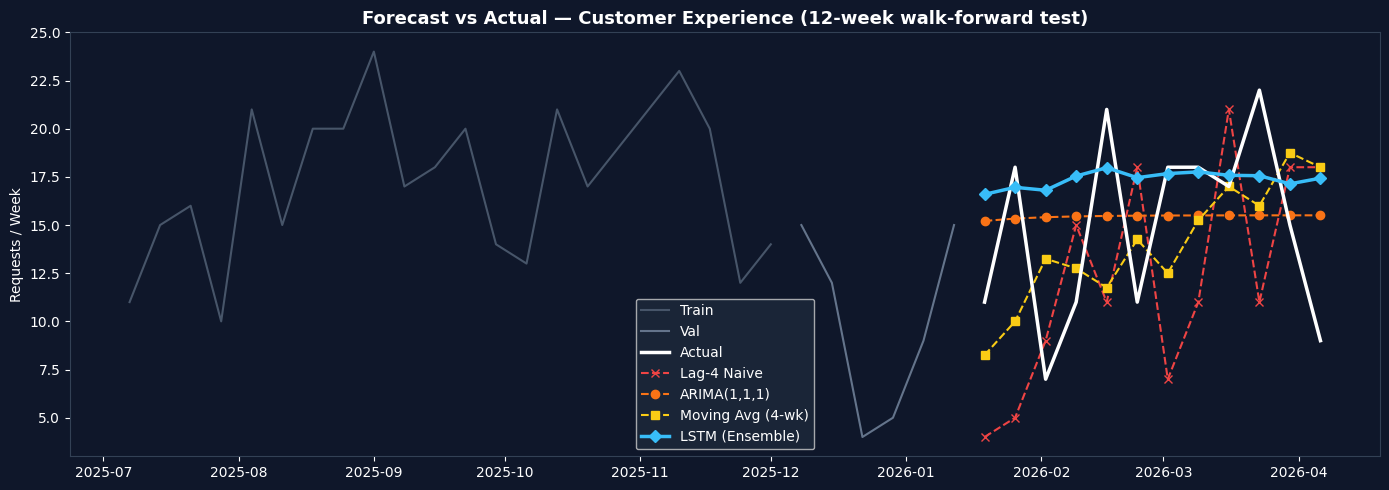

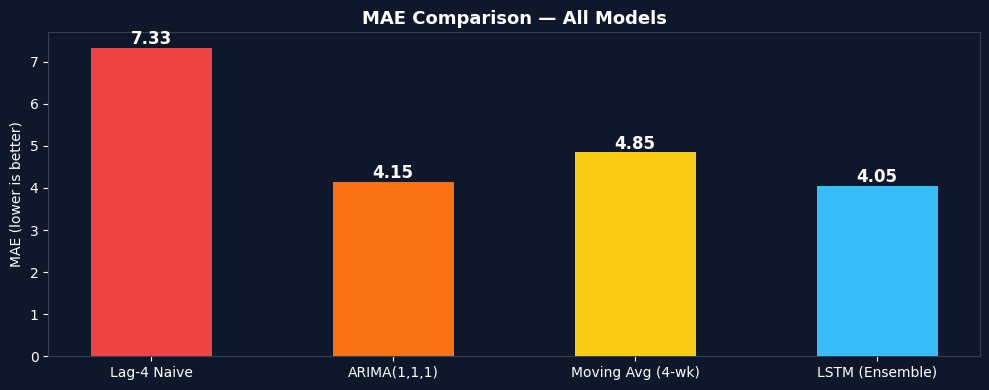

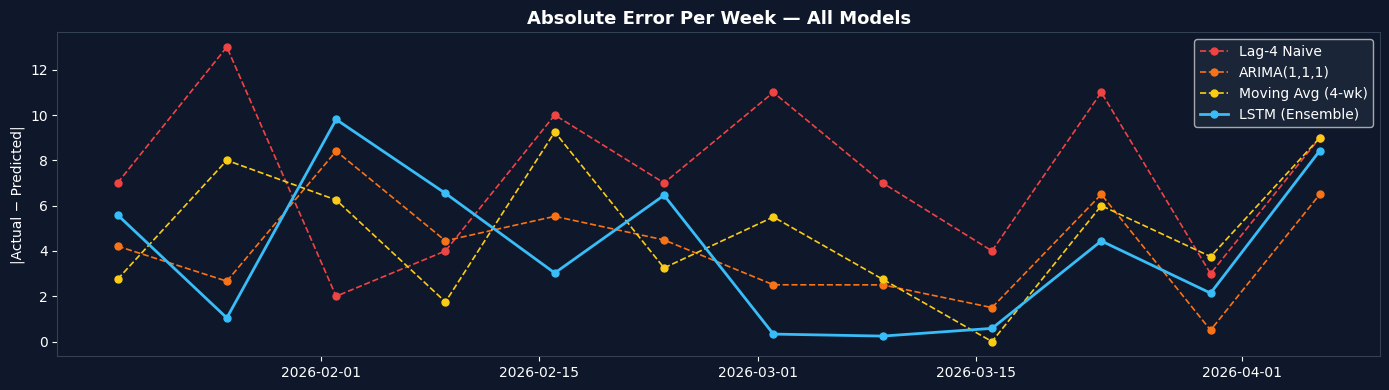

Saved: lstm_forecast_comparison.png | lstm_mae_bar.png | lstm_error_per_week.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# LSTM — Cell F: Final comparison table + visuals
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs("results", exist_ok=True)

# Recompute baselines inline (avoids any stale variable issues)
naive_fc_f = np.array([series_ce.iloc[n - TEST_SIZE + t - 4] for t in range(TEST_SIZE)])
ma_fc_f    = np.array([series_ce.iloc[n - TEST_SIZE + t - 4 : n - TEST_SIZE + t].mean()
                        for t in range(TEST_SIZE)])
arima_fc_f = ARIMA(pd.concat([train, val]), order=(1,1,1)).fit().forecast(steps=TEST_SIZE).values

all_models = {
    "Lag-4 Naive":       naive_fc_f,
    "ARIMA(1,1,1)":      arima_fc_f,
    "Moving Avg (4-wk)": ma_fc_f,
    "LSTM (Ensemble)":   lstm_preds,
}
colors = {
    "Lag-4 Naive":       "#ef4444",
    "ARIMA(1,1,1)":      "#f97316",
    "Moving Avg (4-wk)": "#facc15",
    "LSTM (Ensemble)":   "#38bdf8",
}

# ── Metrics table ──────────────────────────────────────────────────────────────
print(f"{'Model':<22} {'MAE':>7} {'RMSE':>7} {'MAE%':>7}")
print("-" * 48)
for name, preds in all_models.items():
    m  = mean_absolute_error(actual_test, preds)
    r  = np.sqrt(mean_squared_error(actual_test, preds))
    mp = m / actual_test.mean() * 100
    print(f"{name:<22} {m:>7.3f} {r:>7.3f} {mp:>6.1f}%")

# ── Plot 1: Forecast vs Actual ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor("#0f172a"); ax.set_facecolor("#0f172a")
ax.plot(train.index, train.values, color="#475569", lw=1.5, label="Train")
ax.plot(val.index,   val.values,   color="#64748b", lw=1.5, label="Val")
ax.plot(test.index,  actual_test,  color="white",   lw=2.5, label="Actual", zorder=5)
styles = {"Lag-4 Naive":("--","x"), "ARIMA(1,1,1)":("--","o"),
          "Moving Avg (4-wk)":("--","s"), "LSTM (Ensemble)":("-","D")}
for name, preds in all_models.items():
    ls, mk = styles[name]
    ax.plot(test.index, preds, color=colors[name], linestyle=ls,
            marker=mk, markersize=6, lw=2.5 if "LSTM" in name else 1.5,
            label=name, zorder=5 if "LSTM" in name else 3)
ax.set_title("Forecast vs Actual — Customer Experience (12-week walk-forward test)",
             color="white", fontsize=13, fontweight="bold")
ax.set_ylabel("Requests / Week", color="white")
ax.tick_params(colors="white")
for sp in ax.spines.values(): sp.set_color("#334155")
ax.legend(facecolor="#1e293b", labelcolor="white")
plt.tight_layout()
plt.savefig("results/lstm_forecast_comparison.png", dpi=150,
            bbox_inches="tight", facecolor="#0f172a")
plt.show()

# ── Plot 2: MAE bar ────────────────────────────────────────────────────────────
names = list(all_models.keys())
maes  = [mean_absolute_error(actual_test, p) for p in all_models.values()]

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#0f172a"); ax.set_facecolor("#0f172a")
bars = ax.bar(names, maes, color=[colors[n] for n in names], width=0.5, zorder=3)
for bar, v in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.08,
            f"{v:.2f}", ha="center", color="white", fontweight="bold", fontsize=12)
ax.set_title("MAE Comparison — All Models", color="white",
             fontsize=13, fontweight="bold")
ax.set_ylabel("MAE (lower is better)", color="white")
ax.tick_params(colors="white")
for sp in ax.spines.values(): sp.set_color("#334155")
plt.tight_layout()
plt.savefig("results/lstm_mae_bar.png", dpi=150,
            bbox_inches="tight", facecolor="#0f172a")
plt.show()

# ── Plot 3: Per-week absolute error ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
fig.patch.set_facecolor("#0f172a"); ax.set_facecolor("#0f172a")
for name, preds in all_models.items():
    errors = np.abs(actual_test - np.array(preds))
    ax.plot(test.index, errors, color=colors[name], marker="o", markersize=5,
            lw=2 if "LSTM" in name else 1.2,
            linestyle="-" if "LSTM" in name else "--", label=name,
            zorder=5 if "LSTM" in name else 3)
ax.set_title("Absolute Error Per Week — All Models",
             color="white", fontsize=13, fontweight="bold")
ax.set_ylabel("|Actual − Predicted|", color="white")
ax.tick_params(colors="white")
for sp in ax.spines.values(): sp.set_color("#334155")
ax.legend(facecolor="#1e293b", labelcolor="white")
plt.tight_layout()
plt.savefig("results/lstm_error_per_week.png", dpi=150,
            bbox_inches="tight", facecolor="#0f172a")
plt.show()

print("Saved: lstm_forecast_comparison.png | lstm_mae_bar.png | lstm_error_per_week.png")